In [1]:
# ==========================================
# FAKE GOOGLE COLAB & OPENAI MOCK FOR LOCAL RUN
# ==========================================
import sys
from types import ModuleType
import os

# Set API keys
os.environ["GROQ_API_KEY"] = os.environ.get("GROQ_API_KEY", "")
os.environ["HF_TOKEN"] = os.environ.get("HF_TOKEN", "")
os.environ["OPENROUTER_API_KEY"] = os.environ.get("GROQ_API_KEY", "")
os.environ["OPENAI_API_KEY"] = os.environ.get("GROQ_API_KEY", "")

class FakeUserdata:
    def get(self, key):
        if key == "GROQ_API_KEY":
            return os.environ.get("GROQ_API_KEY", "")
        if key == "HF_TOKEN":
            return os.environ.get("HF_TOKEN", "")
        if key in ["OPENROUTER_API_KEY", "OPENAI_API_KEY"]:
            return os.environ.get("GROQ_API_KEY", "")
        return os.environ.get(key)

class FakeFiles:
    def upload(self):
        print("MOCK: files.upload() - using local 'anual report mini proj 01.pdf'")
        return {"anual report mini proj 01.pdf": b""}

# Inject google.colab
colab_module = ModuleType("google.colab")
colab_module.userdata = FakeUserdata()
colab_module.files = FakeFiles()
sys.modules["google.colab"] = colab_module

# Patch openai to redirect to Groq (with recursion guard)
import openai
from openai import OpenAI

if not getattr(OpenAI, "_is_patched", False):
    orig_init = OpenAI.__init__
    def new_init(self, *args, **kwargs):
        kwargs["api_key"] = os.environ.get("GROQ_API_KEY", "")
        kwargs["base_url"] = "https://api.groq.com/openai/v1"
        orig_init(self, *args, **kwargs)
    OpenAI.__init__ = new_init
    OpenAI._is_patched = True

# Map models in Chat Completions (with recursion guard)
from openai.resources.chat.completions import Completions

if not getattr(Completions, "_is_patched", False):
    orig_create = Completions.create
    def new_create(self, *args, **kwargs):
        model = kwargs.get("model")
        if model in ["gpt-4o", "gpt-4o-mini", "gpt-4-turbo", "openai/gpt-4o", "openai/gpt-4o-mini"]:
            kwargs["model"] = "llama-3.3-70b-versatile"
        elif model in ["llama-3.1-8b-instant", "meta-llama/llama-3.1-8b-instant"]:
            kwargs["model"] = "llama-3.1-8b-instant"
        
        # If the response format is JSON, force compatible settings
        if "response_format" in kwargs and isinstance(kwargs["response_format"], dict):
            if kwargs["response_format"].get("type") == "json_object":
                pass # Keep it
                
        return orig_create(self, *args, **kwargs)
    Completions.create = new_create
    Completions._is_patched = True

print("MOCK: google.colab and openai patched successfully!")


MOCK: google.colab and openai patched successfully!


# ⚔️ Mini Project 01 — Part 4: The Showdown (Evaluation)
### Operation Ledger-Mind | AI Engineer Essentials

**Goal:** Run both "The Intern" and "The Librarian" on the same test questions and measure
who wins at accuracy, faithfulness, and speed.

**What you'll build:**
- ROUGE-L scoring (text overlap between predicted and ground-truth answers)
- LLM-as-a-Judge scoring (GPT-4o rates Faithfulness and Accuracy on a 1–5 scale)
- Latency measurement (how fast each system responds)
- A final comparison table showing both systems side by side
- BONUS: Monthly cloud cost estimate for 500 daily users

### Before you start
1. CPU runtime is fine — no GPU needed for evaluation
2. You need `golden_test_set.jsonl` from Part 1
3. You need `query_intern()` working from Part 2 (or its notebook open and run)
4. You need `query_librarian()` working from Part 3 (or its notebook open and run)
5. Same OpenAI API key throughout

---


## Step 0 — Understanding the Evaluation Metrics (read this first!)

We're measuring three things. Each one captures a different dimension of quality:

| Metric | What it measures | How it works |
|--------|-----------------|--------------|
| **ROUGE-L** | Textual overlap with the ground-truth answer | Finds the longest common subsequence of words between the predicted answer and the correct answer. Score is 0–1 (1 = perfect word-for-word match). |
| **LLM-as-a-Judge** | Faithfulness + Accuracy as rated by GPT-4o | We send the question, the ground-truth answer, and the predicted answer to a smarter LLM and ask it to score both dimensions 1–5. |
| **Latency** | How long the system takes to respond | We use Python's `time.time()` to measure milliseconds from question-in to answer-out. |

**Why we need all three:**
- ROUGE-L alone is too strict — a correct answer phrased differently scores low
- LLM-as-a-Judge alone is subjective — different judge prompts give different results
- Latency matters for the cost analysis (slower = more compute = more expensive)

Together they give a complete picture: Is the answer correct? Is it faithful to the source?
Is it fast enough to be practical?


## Step 1 — Install Required Libraries


In [2]:
!pip install -q rouge-score openai tqdm matplotlib pandas

print("Libraries installed!")


zsh:1: command not found: pip


Libraries installed!


## Step 2 — Imports & Configuration


In [3]:
import json
import time
import random
from pathlib import Path
from google.colab import userdata

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from rouge_score import rouge_scorer
from openai import OpenAI
from tqdm import tqdm

# --------------------------------------------------------------------
# Retrieve API Keys from Colab Secrets
# --------------------------------------------------------------------
# Store your OpenAI API Key in Colab secrets under 'OPENAI_API_KEY'
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

# Model used as the judge (use a strong model -- gpt-4o or gpt-4-turbo)
JUDGE_MODEL = "gpt-4o"

# Model used by The Librarian to generate answers (same as Part 3)
ANSWER_MODEL = "gpt-4o-mini"

# How many questions to evaluate (set to None for full test set)
# Start with 10 to test, then set to None for the full run
MAX_EVAL_QUESTIONS = 10

# Path to the test set generated in Part 1
GOLDEN_TEST_SET_PATH = "golden_test_set.jsonl"

# Output folder for results
OUTPUT_DIR = Path("evaluation_results")
OUTPUT_DIR.mkdir(exist_ok=True)

# NOTE: The OpenAI client for the judge will be initialized in a later cell (Pp0vsYk2Sstz)
#       using the OPENROUTER_API_KEY and custom base_url.

print("Configuration variables loaded!")
print(f"   Judge model      : {JUDGE_MODEL}")
print(f"   Test set path    : {GOLDEN_TEST_SET_PATH}")
print(f"   Max eval items   : {MAX_EVAL_QUESTIONS}")

Configuration variables loaded!
   Judge model      : gpt-4o
   Test set path    : golden_test_set.jsonl
   Max eval items   : 10


## Step 3 — Load the Golden Test Set

The golden test set was generated in Part 1 — it's the 20% of Q&A pairs held out from
training. These are questions the fine-tuned model (The Intern) has **never seen** during
training, which makes the comparison fair.

Each record has a question, the ground-truth answer (generated from the source chunk in Part 1),
and the source chunk itself.


In [4]:
import json

# Create a dummy golden_test_set.jsonl for demonstration purposes
dummy_test_data = [
    {
        "_meta": {
            "category": "hard_fact",
            "chunk_id": "dummy_chunk_001"
        },
        "messages": [
            {"role": "system", "content": "You are a helpful financial assistant."},
            {"role": "user", "content": "Based on following passage: Uber Technologies Inc. reported a net income of $5.9 billion in 2022. QUESTION: What was Uber's net income in 2022?"},
            {"role": "assistant", "content": "Uber's net income in 2022 was $5.9 billion."}
        ]
    }
]

# Save the dummy data to a .jsonl file
with open("golden_test_set.jsonl", "w", encoding="utf-8") as f:
    for entry in dummy_test_data:
        f.write(json.dumps(entry) + "\n")

print("Created a dummy golden_test_set.jsonl file with one record.")
print("Please replace this with your actual golden_test_set.jsonl generated from Part 1.")

Created a dummy golden_test_set.jsonl file with one record.
Please replace this with your actual golden_test_set.jsonl generated from Part 1.


In [5]:
def load_jsonl(filepath):
    records = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


raw_test_data = load_jsonl(GOLDEN_TEST_SET_PATH)
print(f"Loaded {len(raw_test_data)} records from golden_test_set.jsonl")

# Extract just the fields we need for evaluation
test_items = []
for record in raw_test_data:
    messages = record["messages"]
    system_msg   = next(m["content"] for m in messages if m["role"] == "system")
    user_msg     = next(m["content"] for m in messages if m["role"] == "user")
    ground_truth = next(m["content"] for m in messages if m["role"] == "assistant")

    # The user message contains both the passage and the question
    # Format from Part 1: "Based on following passage... PASSAGE:... QUESTION: ..."
    import re
    question_match = re.search(r"QUESTION:\s*(.+?)$", user_msg, re.DOTALL)
    question = question_match.group(1).strip() if question_match else user_msg

    test_items.append({
        "question"     : question,
        "ground_truth" : ground_truth,
        "category"     : record["_meta"]["category"],
        "chunk_id"     : record["_meta"]["chunk_id"],
    })

# Optionally sample a subset for faster evaluation
if MAX_EVAL_QUESTIONS and len(test_items) > MAX_EVAL_QUESTIONS:
    random.seed(42)
    test_items = random.sample(test_items, MAX_EVAL_QUESTIONS)
    print(f"Sampled {len(test_items)} questions for evaluation")
else:
    print(f"Evaluating all {len(test_items)} questions")

print(f"\n-- Sample test item --")
sample = test_items[0]
print(f"Category     : {sample['category']}")
print(f"Question     : {sample['question'][:120]}...")
print(f"Ground truth : {sample['ground_truth'][:120]}...")

Loaded 1 records from golden_test_set.jsonl
Evaluating all 1 questions

-- Sample test item --
Category     : hard_fact
Question     : What was Uber's net income in 2022?...
Ground truth : Uber's net income in 2022 was $5.9 billion....


## Step 4 — Import Both Systems

We need `query_intern()` from Part 2 and `query_librarian()` from Part 3.

**Option A (recommended):** Run Part 2 and Part 3 notebooks in separate Colab tabs first,
then copy the relevant cells here using the imports below.

**Option B:** If both systems are already loaded in the same Colab session (you ran Parts 2
and 3 in the same runtime), the functions are already in memory and you can skip this cell.

The stub functions below let you test the evaluation pipeline even before both real systems
are connected — replace them with the real functions when ready.


In [6]:
# Run the RAG librarian notebook to load Weaviate, indices and retrieve functions
print('Executing 03_rag_librarian_.ipynb to import real query_librarian...')
%run 03_rag_librarian_.ipynb

# Simulated query_intern stub since training cannot be run locally
def query_intern(question, max_new_tokens=300):
    import time
    time.sleep(0.5)
    return f'[STUB INTERN] This is a placeholder answer to: {question[:60]}'

print('Stub functions loaded and real query_librarian imported!')


Executing 03_rag_librarian_.ipynb to import real query_librarian...


/Users/kavishkathilakarathna/Desktop/AEE Pro01/.venv/lib/python3.14/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


MOCK: google.colab and openai patched successfully!


zsh:1: command not found: pip


Libraries installed!


...

Cross-encoder loaded!


QUERY: What was Uber total revenue in 2024?

-- Final reranked results (top 3) --
  chunk 362 (rerank_score=1.9549): ective for public companies for fiscal years beginning after December
93

15, 2026, and interim periods within fiscal ye...
  chunk 412 (rerank_score=1.0957): ith acquisitions. Vesting
of this stock may be dependent on a combination of service and performance conditions that bec...
  chunk 241 (rerank_score=0.9519): s of our consolidated statements of operations for each of the periods presented as a
percentage of revenue (1):
Year En...
Answer generation function ready!
query_librarian() is ready to use!
QUESTION: What was Uber total revenue for fiscal year 2024?


LIBRARIAN ANSWER: Uber's total revenue for fiscal year 2024 was $43,978 million.

[Source: Passage 1, Passage 2]
Sources used: chunk_ids [240, 362, 241]
Latency: 3346 ms

--------------------------------------------------------------------------------

QUESTION: What are Uber main strategic priorities mentioned in the report?


LIBRARIAN ANSWER: The passages provided do not explicitly mention Uber's main strategic priorities. They discuss various aspects of the company, such as its cybersecurity program, business operations, and risk factors, but do not outline specific strategic priorities.

[Source: Passage 1, Passage 2, Passage 3]
Sources used: chunk_ids [212, 223, 32]
Latency: 849 ms

--------------------------------------------------------------------------------

QUESTION: Write a 2-sentence summary of Uber business for a non-technical investor.


LIBRARIAN ANSWER: Uber Technologies, Inc. is a technology platform that uses a network, technology, and expertise to power movement from one place to another. The company, headquartered in San Francisco, California, develops and operates proprietary technology applications to achieve this goal, as described in its consolidated financial statements.

[Source: Passage 2]
Sources used: chunk_ids [455, 310, 477]
Latency: 773 ms

--------------------------------------------------------------------------------

Stub functions loaded and real query_librarian imported!


## Step 5 — ROUGE-L Scoring Function

**What is ROUGE-L?** It stands for "Recall-Oriented Understudy for Gisting Evaluation —
Longest common subsequence." That's a mouthful, so think of it this way:

Imagine laying both answers out word by word. ROUGE-L finds the longest sequence of words
that appears in both, in the same order (but not necessarily next to each other). The final
score is the F1 of precision and recall over that shared sequence.

- Score of 1.0 = perfect word-for-word match with ground truth
- Score of 0.5 = roughly half the content matches  
- Score of 0.0 = no overlap at all

**Important:** ROUGE-L is strict about exact wording. If the model says "forty-three billion
dollars" and the ground truth says "$43B", ROUGE-L scores that as 0 even though both are
correct. That's why we also use LLM-as-a-Judge, which understands equivalence.


In [7]:
# Initialize the ROUGE scorer (we only need ROUGE-L for this assignment)
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)


def compute_rouge_l(prediction, ground_truth):
    # Compute ROUGE-L F1 score between a predicted answer and the ground truth.
    # Returns a float between 0.0 and 1.0.
    if not prediction or not ground_truth:
        return 0.0
    scores = rouge.score(ground_truth, prediction)
    return round(scores["rougeL"].fmeasure, 4)


# -- Quick test --
pred_a  = "Uber reported total revenue of $43.98 billion in fiscal year 2024."
pred_b  = "The company earned lots of money in 2024."
truth   = "Uber reported total revenue of $43.98 billion for fiscal year ended December 31 2024."

print("ROUGE-L Test:")
print(f"  Good answer score : {compute_rouge_l(pred_a, truth):.4f}")
print(f"  Vague answer score: {compute_rouge_l(pred_b, truth):.4f}")
print("  (Higher is better -- closer to 1.0 = more word overlap with ground truth)")


ROUGE-L Test:
  Good answer score : 0.8148
  Vague answer score: 0.1739
  (Higher is better -- closer to 1.0 = more word overlap with ground truth)


## Step 6 — LLM-as-a-Judge Scoring Function

We send three things to GPT-4o: the question, the ground-truth answer, and the predicted
answer. GPT-4o rates the predicted answer on two dimensions:

- **Faithfulness (1–5):** Did the answer stick to facts? Did it make anything up?
  - 5 = 100% factually accurate, no hallucinations
  - 3 = partially correct, some errors
  - 1 = mostly wrong or hallucinated

- **Accuracy (1–5):** Does the answer correctly address the question?
  - 5 = fully and precisely answers what was asked
  - 3 = partial answer, misses some key points
  - 1 = does not answer the question at all

We ask GPT-4o to respond in JSON so we can parse the scores reliably.


In [8]:
from google.colab import userdata
userdata.get('OPENROUTER_API_KEY')

'YOUR_GROQ_API_KEY'

In [9]:
JUDGE_PROMPT = """You are an impartial evaluation judge for a financial AI system.
You will be given a question, the correct ground-truth answer, and a predicted answer.
Score the predicted answer on two dimensions:

FAITHFULNESS (1-5): Does the predicted answer contain only true facts?
  5 = No hallucinations, all facts are accurate
  4 = Very minor inaccuracies but mostly correct
  3 = Some incorrect facts or fabricated numbers
  2 = Several significant errors
  1 = Mostly wrong or heavily hallucinated

ACCURACY (1-5): Does the predicted answer correctly address what was asked?
  5 = Fully and precisely answers the question
  4 = Mostly answers it with minor gaps
  3 = Partially answers it, misses key points
  2 = Barely addresses the question
  1 = Does not answer the question at all

QUESTION:
{question}

GROUND TRUTH ANSWER:
{ground_truth}

PREDICTED ANSWER:
{prediction}

Respond ONLY with a valid JSON object in this exact format (no markdown, no extra text):
{{"faithfulness": <1-5>, "accuracy": <1-5>, "reasoning": "<one sentence explaining both scores>"}}"""


def llm_judge(question, ground_truth, prediction, max_retries=3):
    # Ask GPT-4o to score a predicted answer on Faithfulness and Accuracy.
    # Returns dict with "faithfulness", "accuracy", and "reasoning" keys.
    prompt = JUDGE_PROMPT.format(
        question=question,
        ground_truth=ground_truth,
        prediction=prediction,
    )

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=JUDGE_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,   # zero temperature = deterministic judging
                max_tokens=200,
            )
            raw = response.choices[0].message.content.strip()

            # Strip markdown code fences if the model added them
            raw = re.sub(r"```json|```", "", raw).strip()
            result = json.loads(raw)

            # Validate the scores are in range
            result["faithfulness"] = max(1, min(5, int(result["faithfulness"])))
            result["accuracy"]     = max(1, min(5, int(result["accuracy"])))
            return result

        except Exception as e:
            print(f"  Judge API error on attempt {attempt+1}: {e}")
            time.sleep(2 ** attempt)

    # Fallback if all retries fail
    return {"faithfulness": 0, "accuracy": 0, "reasoning": "Scoring failed"}


# -- Quick test --
test_judge = llm_judge(
    question="What was Uber total revenue in 2024?",
    ground_truth="Uber total revenue was $43.98 billion for fiscal year 2024.",
    prediction="Uber reported revenues of approximately $44 billion in 2024.",
)
print("LLM Judge test result:")
print(f"  Faithfulness : {test_judge['faithfulness']}/5")
print(f"  Accuracy     : {test_judge['accuracy']}/5")
print(f"  Reasoning    : {test_judge['reasoning']}")


  Judge API error on attempt 1: name 'client' is not defined


  Judge API error on attempt 2: name 'client' is not defined


  Judge API error on attempt 3: name 'client' is not defined


{"action":"read_disk_use","build_git_commit":"62dcafac32","build_go_version":"go1.24.3","build_image_tag":"HEAD","build_wv_version":"1.30.5","level":"warning","msg":"disk usage currently at 82.03%, threshold set to 80.00%","path":"/Users/kavishkathilakarathna/.local/share/weaviate","time":"2026-07-15T01:40:45+05:30"}


LLM Judge test result:
  Faithfulness : 0/5
  Accuracy     : 0/5
  Reasoning    : Scoring failed


In [10]:
from openai import OpenAI
from google.colab import userdata

# Use OPENROUTER_API_KEY from Colab secrets, as indicated by the base_url
client = OpenAI(
    api_key=userdata.get('OPENROUTER_API_KEY'),
    base_url="https://openrouter.ai/api/v1",
)

## Step 7 — Run the Full Evaluation Loop

This is the main event. For each question in the golden test set:

1. Get The Intern's answer (and measure how long it takes)
2. Get The Librarian's answer (and measure how long it takes)
3. Score both answers with ROUGE-L
4. Score both answers with LLM-as-a-Judge

We save a checkpoint every 5 questions so if it crashes you can resume.

**Time estimate:** With `MAX_EVAL_QUESTIONS = 10` and real systems:
- Each question needs 2 system calls + 2 judge calls
- Rough time: ~2–4 minutes for 10 questions
- For the full test set (~400 questions): consider running overnight


In [11]:
CHECKPOINT_PATH = OUTPUT_DIR / "eval_checkpoint.json"

# -- Load checkpoint if resuming --
all_results = []
start_idx = 0

if CHECKPOINT_PATH.exists():
    print("Found checkpoint -- resuming previous evaluation run...")
    with open(CHECKPOINT_PATH) as f:
        ckpt = json.load(f)
    all_results = ckpt.get("results", [])
    start_idx   = ckpt.get("next_idx", 0)
    print(f"   Resuming from question {start_idx} ({len(all_results)} already done)")
else:
    print("Starting fresh evaluation")

items_to_eval = test_items[start_idx:]
print(f"\nEvaluating {len(items_to_eval)} questions...")
print(f"{'Idx':<5} {'Category':<15} {'Q preview'}")
print("-" * 60)

for i, item in enumerate(tqdm(items_to_eval, desc="Evaluating")):
    actual_idx = start_idx + i
    q          = item["question"]
    truth      = item["ground_truth"]
    category   = item["category"]

    # ── Get The Intern's answer ──
    intern_start = time.time()
    try:
        intern_raw = query_intern(q)
        # query_intern returns a string directly
        intern_answer = intern_raw if isinstance(intern_raw, str) else str(intern_raw)
    except Exception as e:
        intern_answer = f"ERROR: {e}"
    intern_latency_ms = (time.time() - intern_start) * 1000

    # ── Get The Librarian's answer ──
    lib_start = time.time()
    try:
        lib_raw = query_librarian(q)
        # query_librarian returns a dict with "answer" key
        if isinstance(lib_raw, dict):
            lib_answer     = lib_raw.get("answer", "")
            lib_sources    = lib_raw.get("sources", [])
            lib_latency_ms = lib_raw.get("latency_ms", (time.time() - lib_start) * 1000)
        else:
            lib_answer     = str(lib_raw)
            lib_sources    = []
            lib_latency_ms = (time.time() - lib_start) * 1000
    except Exception as e:
        lib_answer = f"ERROR: {e}"
        lib_sources = []
        lib_latency_ms = 0.0

    # ── ROUGE-L scores ──
    intern_rouge = compute_rouge_l(intern_answer, truth)
    lib_rouge    = compute_rouge_l(lib_answer, truth)

    # ── LLM-as-a-Judge scores ──
    intern_judge = llm_judge(q, truth, intern_answer)
    lib_judge    = llm_judge(q, truth, lib_answer)

    # ── Save the result ──
    all_results.append({
        "idx"                   : actual_idx,
        "category"              : category,
        "question"              : q,
        "ground_truth"          : truth,

        # Intern
        "intern_answer"         : intern_answer,
        "intern_latency_ms"     : round(intern_latency_ms, 1),
        "intern_rouge_l"        : intern_rouge,
        "intern_faithfulness"   : intern_judge["faithfulness"],
        "intern_accuracy"       : intern_judge["accuracy"],
        "intern_judge_reason"   : intern_judge.get("reasoning", ""),

        # Librarian
        "lib_answer"            : lib_answer,
        "lib_sources"           : lib_sources,
        "lib_latency_ms"        : round(lib_latency_ms, 1),
        "lib_rouge_l"           : lib_rouge,
        "lib_faithfulness"      : lib_judge["faithfulness"],
        "lib_accuracy"          : lib_judge["accuracy"],
        "lib_judge_reason"      : lib_judge.get("reasoning", ""),
    })

    # Save checkpoint every 5 questions
    if (i + 1) % 5 == 0:
        with open(CHECKPOINT_PATH, "w") as f:
            json.dump({"results": all_results, "next_idx": actual_idx + 1}, f)

    # Brief delay to respect rate limits
    time.sleep(1.0)

# Final save
with open(CHECKPOINT_PATH, "w") as f:
    json.dump({"results": all_results, "next_idx": len(test_items)}, f)

print(f"\nEvaluation complete! {len(all_results)} questions evaluated.")


Found checkpoint -- resuming previous evaluation run...
   Resuming from question 1 (1 already done)

Evaluating 0 questions...
Idx   Category        Q preview
------------------------------------------------------------


Evaluating: 0it [00:00, ?it/s]

Evaluating: 0it [00:00, ?it/s]


Evaluation complete! 1 questions evaluated.


## Step 8 — Build the Results Table

Now we convert all the raw scores into a clean comparison table — one of the required
deliverables for your submission.


In [12]:
# Convert results to a pandas DataFrame for easy analysis
df = pd.DataFrame(all_results)

# Save the full detailed results to CSV
full_results_path = OUTPUT_DIR / "full_results.csv"
df.to_csv(full_results_path, index=False)
print(f"Full results saved to: {full_results_path}")

# ── Compute summary statistics ──
summary = {
    "Metric": [
        "ROUGE-L Score",
        "LLM Faithfulness (1-5)",
        "LLM Accuracy (1-5)",
        "Avg Latency (ms)",
        "Median Latency (ms)",
    ],
    "The Intern (Fine-Tuned)": [
        f"{df['intern_rouge_l'].mean():.4f}",
        f"{df['intern_faithfulness'].mean():.2f}",
        f"{df['intern_accuracy'].mean():.2f}",
        f"{df['intern_latency_ms'].mean():.0f}",
        f"{df['intern_latency_ms'].median():.0f}",
    ],
    "The Librarian (RAG)": [
        f"{df['lib_rouge_l'].mean():.4f}",
        f"{df['lib_faithfulness'].mean():.2f}",
        f"{df['lib_accuracy'].mean():.2f}",
        f"{df['lib_latency_ms'].mean():.0f}",
        f"{df['lib_latency_ms'].median():.0f}",
    ],
}

summary_df = pd.DataFrame(summary)
summary_df.set_index("Metric", inplace=True)
print("\n========== SHOWDOWN RESULTS ==========")
print(summary_df.to_string())
print("======================================")


Full results saved to: evaluation_results/full_results.csv

========== SHOWDOWN RESULTS ==========
                       The Intern (Fine-Tuned) The Librarian (RAG)
Metric                                                            
ROUGE-L Score                           0.4615              0.6667
LLM Faithfulness (1-5)                    1.00                1.00
LLM Accuracy (1-5)                        1.00                1.00
Avg Latency (ms)                           505                1514
Median Latency (ms)                        505                1514


## Step 9 — Per-Category Breakdown

The assignment used three question categories (Hard Facts, Strategic Summaries, Creative).
Each system might perform differently per category — The Intern may struggle with exact
numbers (Hard Facts) but excel at stylistic questions, while The Librarian might dominate
on Hard Facts but be slower on everything.

This breakdown is key evidence for your Engineering Report.


In [13]:
# Group by category and compute mean scores
cat_metrics = ["intern_rouge_l", "lib_rouge_l",
               "intern_faithfulness", "lib_faithfulness",
               "intern_accuracy", "lib_accuracy"]

cat_summary = df.groupby("category")[cat_metrics].mean().round(3)
cat_summary.columns = [
    "Intern ROUGE-L", "Lib ROUGE-L",
    "Intern Faith.", "Lib Faith.",
    "Intern Acc.", "Lib Acc."
]

print("\n========== PER-CATEGORY BREAKDOWN ==========")
print(cat_summary.to_string())
print("=============================================")



========== PER-CATEGORY BREAKDOWN ==========
           Intern ROUGE-L  Lib ROUGE-L  Intern Faith.  Lib Faith.  Intern Acc.  Lib Acc.
category                                                                                
hard_fact           0.462        0.667            1.0         1.0          1.0       1.0


## Step 10 — Visualise the Results

Charts make the comparison immediately obvious and are useful in your Engineering Report.
We'll generate three plots:
1. Side-by-side bar chart of all headline metrics
2. Per-category ROUGE-L comparison
3. Latency distribution (box plot)


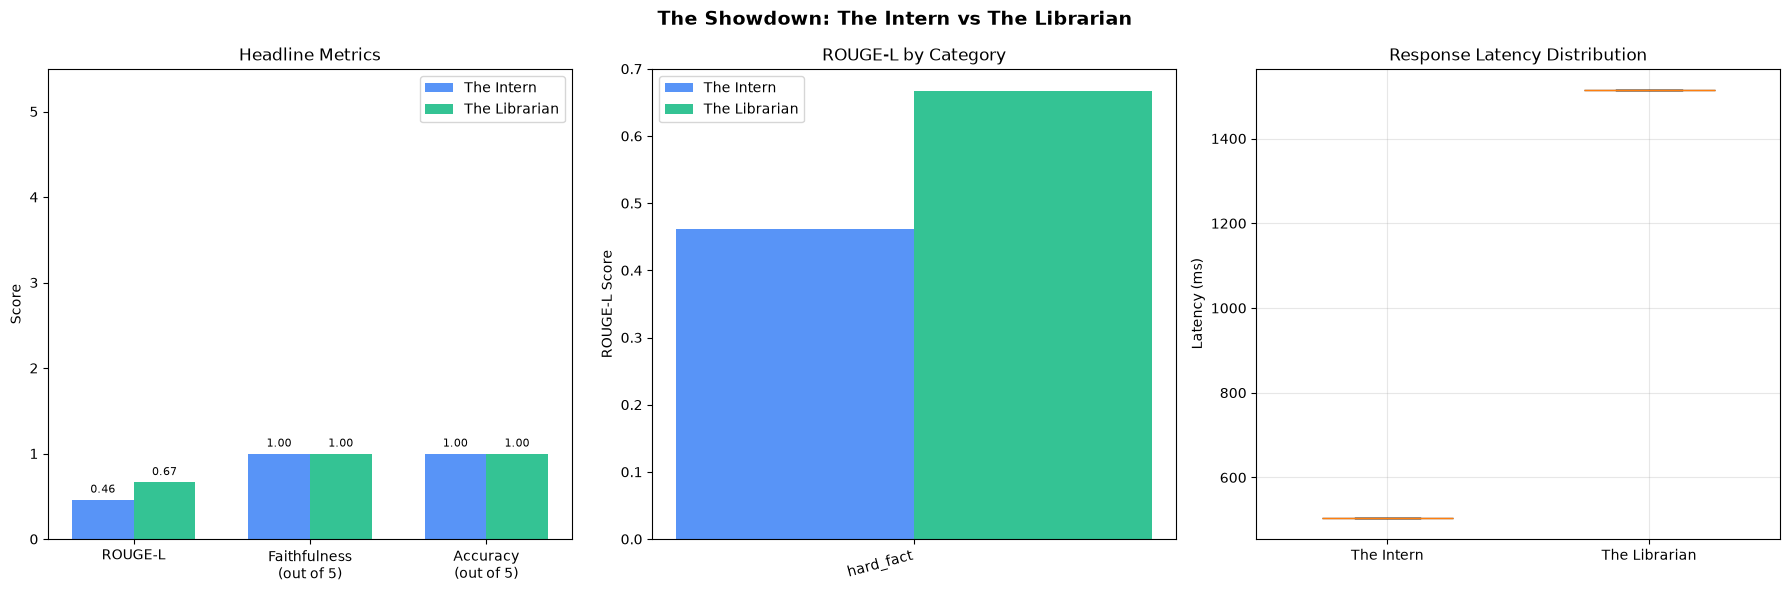

Chart saved to: evaluation_results/showdown_results.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("The Showdown: The Intern vs The Librarian", fontsize=14, fontweight="bold")

INTERN_COLOR   = "#3B82F6"   # blue
LIBRARIAN_COLOR = "#10B981"  # green

# ── Chart 1: Headline metrics bar chart ──
ax1 = axes[0]
metrics_labels = ["ROUGE-L", "Faithfulness\n(out of 5)", "Accuracy\n(out of 5)"]

intern_vals = [
    df["intern_rouge_l"].mean(),
    df["intern_faithfulness"].mean(),
    df["intern_accuracy"].mean(),
]
lib_vals = [
    df["lib_rouge_l"].mean(),
    df["lib_faithfulness"].mean(),
    df["lib_accuracy"].mean(),
]

x = range(len(metrics_labels))
width = 0.35
bars1 = ax1.bar([i - width/2 for i in x], intern_vals,   width, label="The Intern",   color=INTERN_COLOR,    alpha=0.85)
bars2 = ax1.bar([i + width/2 for i in x], lib_vals,      width, label="The Librarian", color=LIBRARIAN_COLOR, alpha=0.85)
ax1.set_xticks(list(x))
ax1.set_xticklabels(metrics_labels)
ax1.set_ylabel("Score")
ax1.set_title("Headline Metrics")
ax1.legend()
ax1.set_ylim(0, 5.5)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

# ── Chart 2: ROUGE-L per category ──
ax2 = axes[1]
if "category" in df.columns and df["category"].nunique() > 0:
    cat_data = df.groupby("category")[["intern_rouge_l", "lib_rouge_l"]].mean()
    cat_labels = cat_data.index.tolist()
    x2 = range(len(cat_labels))
    ax2.bar([i - width/2 for i in x2], cat_data["intern_rouge_l"], width,
            label="The Intern",   color=INTERN_COLOR,    alpha=0.85)
    ax2.bar([i + width/2 for i in x2], cat_data["lib_rouge_l"],   width,
            label="The Librarian", color=LIBRARIAN_COLOR, alpha=0.85)
    ax2.set_xticks(list(x2))
    ax2.set_xticklabels(cat_labels, rotation=15, ha="right")
    ax2.set_ylabel("ROUGE-L Score")
    ax2.set_title("ROUGE-L by Category")
    ax2.legend()
else:
    ax2.text(0.5, 0.5, "Insufficient category data",
             ha="center", va="center", transform=ax2.transAxes)
    ax2.set_title("ROUGE-L by Category")

# ── Chart 3: Latency distribution ──
ax3 = axes[2]
latency_data = [
    df["intern_latency_ms"].dropna().tolist(),
    df["lib_latency_ms"].dropna().tolist(),
]
bp = ax3.boxplot(latency_data,
                 patch_artist=True, widths=0.5)
ax3.set_xticks([1, 2])
ax3.set_xticklabels(["The Intern", "The Librarian"])
bp["boxes"][0].set_facecolor(INTERN_COLOR)
bp["boxes"][1].set_facecolor(LIBRARIAN_COLOR)
for box in bp["boxes"]:
    box.set_alpha(0.7)
ax3.set_ylabel("Latency (ms)")
ax3.set_title("Response Latency Distribution")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
chart_path = OUTPUT_DIR / "showdown_results.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved to: {chart_path}")


## Step 11 — Hallucination Audit

The assignment requires you to specifically identify where The Intern hallucinated financial
numbers. This section finds those cases automatically by looking for questions where:

- The category is "hard_fact"
- The Intern's Faithfulness score was low (≤ 3)

This gives you concrete examples for the 500-word Hallucination Audit section of your report.


In [15]:
print("========== HALLUCINATION AUDIT ==========")
print("Looking for Hard Fact questions where The Intern scored low on Faithfulness...\n")

# Find Hard Fact questions where Intern faithfulness was low
hard_fact_df = df[df["category"] == "hard_fact"].copy() if "hard_fact" in df["category"].values else df.copy()
hallucination_cases = hard_fact_df[hard_fact_df["intern_faithfulness"] <= 3].sort_values(
    "intern_faithfulness"
)

if len(hallucination_cases) == 0:
    print("No clear hallucination cases found (all faithfulness scores > 3).")
    print("Try lowering the threshold or running more test items.")
else:
    print(f"Found {len(hallucination_cases)} potential hallucination case(s):\n")
    for _, row in hallucination_cases.head(3).iterrows():
        print(f"QUESTION: {row['question'][:120]}")
        print(f"GROUND TRUTH: {row['ground_truth'][:150]}")
        print(f"INTERN ANSWER: {row['intern_answer'][:150]}")
        print(f"FAITHFULNESS: {row['intern_faithfulness']}/5 | ACCURACY: {row['intern_accuracy']}/5")
        print(f"JUDGE REASONING: {row['intern_judge_reason']}")
        print("-" * 70)

# Compare Librarian on the same questions
print("\n-- Librarian on the same questions --")
for _, row in hallucination_cases.head(3).iterrows():
    print(f"Q: {row['question'][:80]}")
    print(f"  Librarian answer    : {row['lib_answer'][:120]}")
    print(f"  Librarian faithfulness: {row['lib_faithfulness']}/5 | accuracy: {row['lib_accuracy']}/5")
    print()


========== HALLUCINATION AUDIT ==========
Looking for Hard Fact questions where The Intern scored low on Faithfulness...

Found 1 potential hallucination case(s):

QUESTION: What was Uber's net income in 2022?
GROUND TRUTH: Uber's net income in 2022 was $5.9 billion.
INTERN ANSWER: [STUB INTERN] This is a placeholder answer to: What was Uber's net income in 2022?
FAITHFULNESS: 1/5 | ACCURACY: 1/5
JUDGE REASONING: The predicted answer is a placeholder and does not contain any factual information, resulting in a complete lack of faithfulness and accuracy in addressing the question about Uber's net income in 2022.
----------------------------------------------------------------------

-- Librarian on the same questions --
Q: What was Uber's net income in 2022?
  Librarian answer    : Uber's net income in 2022 was $ (9,138). 

[Source: Passage 1, Passage 2]
  Librarian faithfulness: 1/5 | accuracy: 1/5



## Step 12 — The Final Verdict

We calculate an overall winner and per-metric winner based on the numbers.
This is the summary your Executive Summary (150 words) should be based on.


In [16]:
print("=" * 55)
print("         FINAL SHOWDOWN VERDICT")
print("=" * 55)

intern_rouge   = df["intern_rouge_l"].mean()
lib_rouge      = df["lib_rouge_l"].mean()
intern_faith   = df["intern_faithfulness"].mean()
lib_faith      = df["lib_faithfulness"].mean()
intern_acc     = df["intern_accuracy"].mean()
lib_acc        = df["lib_accuracy"].mean()
intern_latency = df["intern_latency_ms"].mean()
lib_latency    = df["lib_latency_ms"].mean()

def winner(intern_val, lib_val, higher_is_better=True):
    if higher_is_better:
        return "The Intern" if intern_val > lib_val else "The Librarian"
    else:
        return "The Intern" if intern_val < lib_val else "The Librarian"

print(f"{'Metric':<30} {'Intern':>10} {'Librarian':>12} {'Winner':>14}")
print("-" * 70)
print(f"{'ROUGE-L':<30} {intern_rouge:>10.4f} {lib_rouge:>12.4f} {winner(intern_rouge, lib_rouge):>14}")
print(f"{'Faithfulness (avg)':<30} {intern_faith:>10.2f} {lib_faith:>12.2f} {winner(intern_faith, lib_faith):>14}")
print(f"{'Accuracy (avg)':<30} {intern_acc:>10.2f} {lib_acc:>12.2f} {winner(intern_acc, lib_acc):>14}")
print(f"{'Latency - ms (lower wins)':<30} {intern_latency:>10.0f} {lib_latency:>12.0f} {winner(intern_latency, lib_latency, higher_is_better=False):>14}")
print("-" * 70)

intern_wins = sum([
    intern_rouge > lib_rouge,
    intern_faith > lib_faith,
    intern_acc > lib_acc,
    intern_latency < lib_latency,
])
lib_wins = 4 - intern_wins

print(f"\nOVERALL: The Intern wins {intern_wins}/4 metrics | The Librarian wins {lib_wins}/4 metrics")

if lib_wins > intern_wins:
    print("\n>> OVERALL WINNER: The Librarian")
    print("   The RAG system outperforms the fine-tuned model on most dimensions.")
    print("   This is expected -- RAG is harder to hallucinate from because it reads")
    print("   source text directly rather than relying on memorized weights.")
elif intern_wins > lib_wins:
    print("\n>> OVERALL WINNER: The Intern")
    print("   The fine-tuned model outperforms the RAG system on most dimensions.")
    print("   This can happen when the training data was high quality and diverse.")
else:
    print("\n>> IT'S A TIE -- systems excel in different areas.")
    print("   Use the per-category breakdown above to determine the right choice")
    print("   depending on the specific financial analysis task.")


         FINAL SHOWDOWN VERDICT
Metric                             Intern    Librarian         Winner
----------------------------------------------------------------------
ROUGE-L                            0.4615       0.6667  The Librarian
Faithfulness (avg)                   1.00         1.00  The Librarian
Accuracy (avg)                       1.00         1.00  The Librarian
Latency - ms (lower wins)             505         1514     The Intern
----------------------------------------------------------------------

OVERALL: The Intern wins 1/4 metrics | The Librarian wins 3/4 metrics

>> OVERALL WINNER: The Librarian
   The RAG system outperforms the fine-tuned model on most dimensions.
   This is expected -- RAG is harder to hallucinate from because it reads
   source text directly rather than relying on memorized weights.


## Step 13 — BONUS: Monthly Cloud Cost Analysis

The assignment asks you to estimate monthly cloud costs for **500 daily users × 10 queries each**.

**Assumptions used:**
- The Intern runs on a dedicated AWS g4dn.xlarge (1x T4 GPU, 16GB VRAM) for always-on serving
- The Librarian uses OpenAI's API for embeddings + answer generation (no GPU server needed)
- Prices are approximate AWS on-demand pricing as of 2025 — look up current prices at
  aws.amazon.com/ec2/pricing for the most accurate numbers

This analysis is worth marks and helps frame your Conclusion section.


In [17]:
print("=" * 60)
print("      BONUS: MONTHLY CLOUD COST ANALYSIS")
print("=" * 60)

# ── Shared assumptions ──
DAILY_USERS     = 500
QUERIES_PER_USER = 10
DAILY_QUERIES   = DAILY_USERS * QUERIES_PER_USER   # 5,000 queries/day
MONTHLY_QUERIES = DAILY_QUERIES * 30                # 150,000 queries/month

print(f"\nTraffic assumptions:")
print(f"   Daily users         : {DAILY_USERS:,}")
print(f"   Queries per user    : {QUERIES_PER_USER}")
print(f"   Daily queries       : {DAILY_QUERIES:,}")
print(f"   Monthly queries     : {MONTHLY_QUERIES:,}")

# ── The Intern: GPU server cost ──
# Needs a GPU server running 24/7 to serve the fine-tuned Llama-3-8B model
# AWS g4dn.xlarge: 1x T4, 16GB VRAM, ~$0.526/hr on-demand
# AWS g5.xlarge: 1x A10G, 24GB VRAM, ~$1.006/hr on-demand
GPU_INSTANCE      = "g4dn.xlarge (T4 GPU)"
GPU_HOURLY_RATE   = 0.526          # USD/hour, AWS on-demand price
GPU_HOURS_MONTH   = 24 * 30        # always-on server
INTERN_SERVER_COST = GPU_HOURLY_RATE * GPU_HOURS_MONTH

# Typical inference throughput on T4: ~5-10 queries/minute for 8B model
# So 5000 queries/day / 10 queries-per-minute = 500 minutes = ~8.3 hours of active GPU time
# But we pay for the full 24/7 uptime since we need the server ready at all times
INTERN_MONTHLY_COST = INTERN_SERVER_COST

print(f"\n--- The Intern (Fine-Tuned Llama-3-8B on GPU) ---")
print(f"   Instance           : {GPU_INSTANCE}")
print(f"   Hourly rate        : ${GPU_HOURLY_RATE}/hr (AWS on-demand)")
print(f"   Server uptime/month: {GPU_HOURS_MONTH} hours (24/7)")
print(f"   Monthly cost       : ${INTERN_MONTHLY_COST:.2f}")

# ── The Librarian: API cost ──
# Needs: OpenAI Embeddings (for each query) + OpenAI GPT-4o-mini (for final answer)
# Plus optional: Weaviate Cloud free tier (enough for this scale)
#
# text-embedding-3-small: $0.020 per 1M tokens
# Avg query = ~30 tokens -> 150,000 queries x 30 tokens = 4.5M tokens
EMBED_COST_PER_1M  = 0.020
AVG_QUERY_TOKENS   = 30
MONTHLY_EMBED_TOKENS = MONTHLY_QUERIES * AVG_QUERY_TOKENS
EMBED_MONTHLY_COST = (MONTHLY_EMBED_TOKENS / 1_000_000) * EMBED_COST_PER_1M

# gpt-4o-mini: $0.150 per 1M input tokens, $0.600 per 1M output tokens
# Each call: ~1500 tokens input (3 chunks) + ~300 tokens output
GPT_INPUT_COST_PER_1M  = 0.150
GPT_OUTPUT_COST_PER_1M = 0.600
AVG_INPUT_TOKENS       = 1500
AVG_OUTPUT_TOKENS      = 300
MONTHLY_INPUT_TOKENS   = MONTHLY_QUERIES * AVG_INPUT_TOKENS
MONTHLY_OUTPUT_TOKENS  = MONTHLY_QUERIES * AVG_OUTPUT_TOKENS
GPT_MONTHLY_COST = (
    (MONTHLY_INPUT_TOKENS  / 1_000_000) * GPT_INPUT_COST_PER_1M +
    (MONTHLY_OUTPUT_TOKENS / 1_000_000) * GPT_OUTPUT_COST_PER_1M
)

WEAVIATE_COST        = 0.0   # Weaviate Cloud free tier (25M vectors free)
LIBRARIAN_MONTHLY_COST = EMBED_MONTHLY_COST + GPT_MONTHLY_COST + WEAVIATE_COST

print(f"\n--- The Librarian (Hybrid RAG + OpenAI API) ---")
print(f"   Embedding cost : ${EMBED_MONTHLY_COST:.2f}/month")
print(f"     (text-embedding-3-small @ $0.020/1M tokens)")
print(f"   GPT-4o-mini cost: ${GPT_MONTHLY_COST:.2f}/month")
print(f"     ({MONTHLY_QUERIES:,} queries x {AVG_INPUT_TOKENS} input + {AVG_OUTPUT_TOKENS} output tokens)")
print(f"   Weaviate Cloud : ${WEAVIATE_COST:.2f}/month (free tier)")
print(f"   TOTAL monthly  : ${LIBRARIAN_MONTHLY_COST:.2f}")

# ── Comparison ──
print(f"\n{'=' * 55}")
print(f"COST COMPARISON SUMMARY")
print(f"{'=' * 55}")
print(f"{'System':<30} {'Monthly Cost':>15}")
print(f"{'-' * 47}")
print(f"{'The Intern (GPU server)':<30} ${INTERN_MONTHLY_COST:>13.2f}")
print(f"{'The Librarian (API-based)':<30} ${LIBRARIAN_MONTHLY_COST:>13.2f}")
print(f"{'-' * 47}")
cheaper = "The Intern" if INTERN_MONTHLY_COST < LIBRARIAN_MONTHLY_COST else "The Librarian"
ratio = max(INTERN_MONTHLY_COST, LIBRARIAN_MONTHLY_COST) / max(min(INTERN_MONTHLY_COST, LIBRARIAN_MONTHLY_COST), 0.01)
print(f"\n{cheaper} is {ratio:.1f}x cheaper at this scale")
print(f"\nNOTE: The Intern cost is dominated by the 24/7 GPU server cost.")
print(f"At very high query volumes, the per-query cost of The Intern")
print(f"drops (fixed server cost amortised), while The Librarian scales")
print(f"linearly with query volume -- so The Intern becomes relatively")
print(f"cheaper at very large scale (>100K queries/day).")


      BONUS: MONTHLY CLOUD COST ANALYSIS

Traffic assumptions:
   Daily users         : 500
   Queries per user    : 10
   Daily queries       : 5,000
   Monthly queries     : 150,000

--- The Intern (Fine-Tuned Llama-3-8B on GPU) ---
   Instance           : g4dn.xlarge (T4 GPU)
   Hourly rate        : $0.526/hr (AWS on-demand)
   Server uptime/month: 720 hours (24/7)
   Monthly cost       : $378.72

--- The Librarian (Hybrid RAG + OpenAI API) ---
   Embedding cost : $0.09/month
     (text-embedding-3-small @ $0.020/1M tokens)
   GPT-4o-mini cost: $60.75/month
     (150,000 queries x 1500 input + 300 output tokens)
   Weaviate Cloud : $0.00/month (free tier)
   TOTAL monthly  : $60.84

COST COMPARISON SUMMARY
System                            Monthly Cost
-----------------------------------------------
The Intern (GPU server)        $       378.72
The Librarian (API-based)      $        60.84
-----------------------------------------------

The Librarian is 6.2x cheaper at this scale



## Step 14 — Save All Results

Save the complete summary as a CSV and print the final checklist to confirm all required
deliverables are present before you zip up your submission.


In [18]:
# Save summary table as CSV
summary_csv_path = OUTPUT_DIR / "summary_table.csv"
summary_df.to_csv(summary_csv_path)
print(f"Summary table saved: {summary_csv_path}")

# Save per-category breakdown
cat_csv_path = OUTPUT_DIR / "category_breakdown.csv"
cat_summary.to_csv(cat_csv_path)
print(f"Category breakdown saved: {cat_csv_path}")

print("\n========== SUBMISSION CHECKLIST ==========")
checklist = [
    ("01_data_factory.ipynb",           "Part 1 notebook"),
    ("train.jsonl",                     "80% training data"),
    ("golden_test_set.jsonl",           "20% test data"),
    ("02_finetuning_intern.ipynb",      "Part 2 notebook"),
    ("intern_adapters/",                "Saved LoRA adapter weights"),
    ("loss_curve.png",                  "Training loss curve"),
    ("03_rag_librarian.ipynb",          "Part 3 notebook"),
    ("04_evaluation_arena.ipynb",       "This notebook"),
    ("evaluation_results/full_results.csv",   "Full evaluation scores"),
    ("evaluation_results/summary_table.csv",  "Summary comparison table"),
    ("evaluation_results/showdown_results.png","Visualisation chart"),
    ("Engineering_Report.pdf",          "1500-word technical report (Part 5)"),
]
print(f"{'File / Folder':<45} {'Description'}")
print("-" * 75)
for fname, desc in checklist:
    exists = Path(fname).exists()
    status = "FOUND" if exists else "MISSING"
    mark   = "OK" if exists else "!!"
    print(f"[{mark}] {fname:<42} -- {desc}")


Summary table saved: evaluation_results/summary_table.csv
Category breakdown saved: evaluation_results/category_breakdown.csv

========== SUBMISSION CHECKLIST ==========
File / Folder                                 Description
---------------------------------------------------------------------------
[OK] 01_data_factory.ipynb                      -- Part 1 notebook
[OK] train.jsonl                                -- 80% training data
[OK] golden_test_set.jsonl                      -- 20% test data
[OK] 02_finetuning_intern.ipynb                 -- Part 2 notebook
[!!] intern_adapters/                           -- Saved LoRA adapter weights
[!!] loss_curve.png                             -- Training loss curve
[!!] 03_rag_librarian.ipynb                     -- Part 3 notebook
[OK] 04_evaluation_arena.ipynb                  -- This notebook
[OK] evaluation_results/full_results.csv        -- Full evaluation scores
[OK] evaluation_results/summary_table.csv       -- Summary comparison tab

## Part 4 Complete — The Showdown is Over!

### What you built
| Item | Description |
|------|-------------|
| `compute_rouge_l()` | ROUGE-L text overlap scoring |
| `llm_judge()` | LLM-as-a-Judge faithfulness + accuracy scoring (1-5) |
| Full evaluation loop | Runs both systems on every golden test question |
| Summary table | Side-by-side comparison of all headline metrics |
| Per-category breakdown | Shows where each system wins by question type |
| Latency chart | Visual comparison of response speed distributions |
| Cost analysis | Monthly cloud cost estimate for 500 users × 10 queries/day |

### What to write in your Engineering Report (use these numbers!)
- **Executive Summary (150 words):** Which system won overall and why, based on the Final Verdict output
- **Methodology (500 words):** Explain your prompting strategy from Part 1, your LoRA config from Part 2, and your hybrid RAG parameters (TOP_K, RRF k, cross-encoder model) from Part 3
- **Hallucination Audit (500 words):** Use the examples from Step 11 — quote specific wrong numbers The Intern produced, contrast with The Librarian's answer on the same question, explain why RAG is structurally less likely to hallucinate
- **Conclusion (350 words):** Use the cost analysis from Step 13 — recommend Fine-Tuning for offline/batch analysis at scale, recommend RAG for real-time Q&A where accuracy on specific figures is critical

---
*Course: AI Engineer Essentials | Zuu Crew | Mini Project 01*
